In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

In [2]:
train_ds = pd.read_csv('train.csv')
test_ds = pd.read_csv('test.csv')

In [3]:
train_ds.head(5)

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


In [4]:
train_ds.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   8693 non-null   object 
 1   HomePlanet    8492 non-null   object 
 2   CryoSleep     8476 non-null   object 
 3   Cabin         8494 non-null   object 
 4   Destination   8511 non-null   object 
 5   Age           8514 non-null   float64
 6   VIP           8490 non-null   object 
 7   RoomService   8512 non-null   float64
 8   FoodCourt     8510 non-null   float64
 9   ShoppingMall  8485 non-null   float64
 10  Spa           8510 non-null   float64
 11  VRDeck        8505 non-null   float64
 12  Name          8493 non-null   object 
 13  Transported   8693 non-null   bool   
dtypes: bool(1), float64(6), object(7)
memory usage: 891.5+ KB


смотрим где есть пропуски

In [5]:
train_ds.isnull().sum()

,0
PassengerId,0
HomePlanet,201
CryoSleep,217
Cabin,199
Destination,182
Age,179
VIP,203
RoomService,181
FoodCourt,183
ShoppingMall,208


In [6]:
transported = train_ds[train_ds['Transported'] == True]
not_transported = train_ds[train_ds['Transported'] == False]

print ("Transported: %i (%.1f%%)"%(len(transported), (len(transported))/len(train_ds)*100.0))
print ("Not Transported: %i (%.1f%%)"%(len(not_transported), (len(not_transported))/len(train_ds)*100.0))

Transported: 4378 (50.4%)
Not Transported: 4315 (49.6%)


криосон и вип заполним самым популярным значением

In [7]:
train_ds['CryoSleep'] = train_ds['CryoSleep'].fillna(train_ds['CryoSleep'].mode()[0])
train_ds['VIP'] = train_ds['VIP'].fillna(train_ds['VIP'].mode()[0])

/tmp/ipython-input-4237549071.py:1: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  train_ds['CryoSleep'] = train_ds['CryoSleep'].fillna(train_ds['CryoSleep'].mode()[0])
/tmp/ipython-input-4237549071.py:2: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  train_ds['VIP'] = train_ds['VIP'].fillna(train_ds['VIP'].mode()[0])


In [8]:
train_ds.HomePlanet.value_counts()

,count
HomePlanet,
Earth,4602
Europa,2131
Mars,1759


HomePlanet заполним чаще всего встречающейся планетой (Earth)

<Axes: xlabel='HomePlanet', ylabel='Transported'>

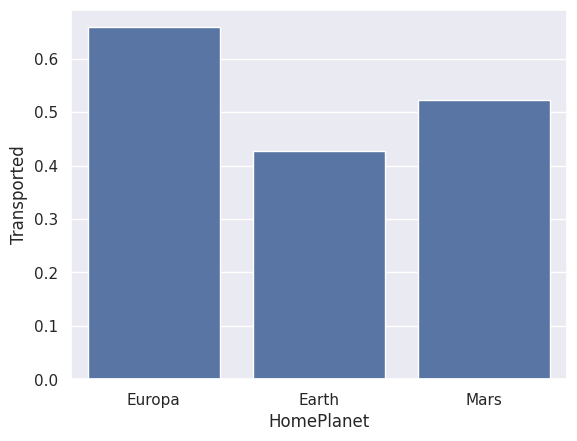

In [9]:
train_ds['HomePlanet'] = train_ds['HomePlanet'].fillna('Earth')
sns.barplot(x='HomePlanet', y='Transported', data=train_ds, errorbar=None)

видно, что шансы на транспортировку выше у людей с HomePlanet Europa

In [10]:
train_ds.Destination.value_counts()

,count
Destination,
TRAPPIST-1e,5915
55 Cancri e,1800
PSO J318.5-22,796


<Axes: xlabel='Destination', ylabel='Transported'>

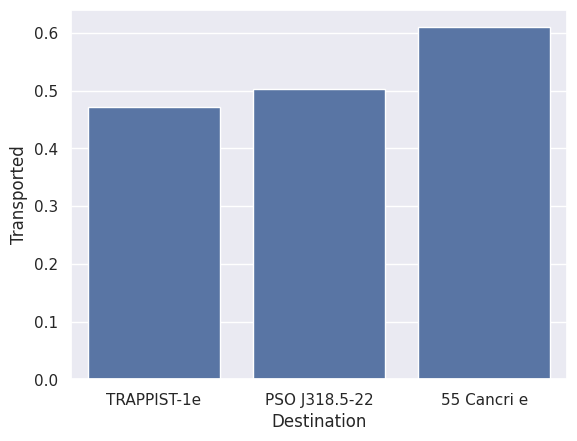

In [11]:
train_ds['Destination'] = train_ds['Destination'].fillna('TRAPPIST-1e')
sns.barplot(x='Destination', y='Transported', data=train_ds, errorbar=None)

пропуски в Destination также заполнили самым популярным направлением

у людей с Destination TRAPPIST-1e и PSO J318.5-22 шансы на трансп. близки

у 55 Cancri e выше

In [12]:
min_age = train_ds[
    (train_ds['RoomService'] > 0) |
    (train_ds['FoodCourt'] > 0) |
    (train_ds['Spa'] > 0) |
    (train_ds['VRDeck'] > 0) |
    (train_ds['ShoppingMall'] > 0)
]['Age'].min()

print(min_age)

13.0


дети до 13 лет не тратят деньги, воспользуемся этой информацией при дальнейшем заполнении пропусков

дети до 13 лет и те, кто в криосне затрат не имеют, остальных заполняем медианой

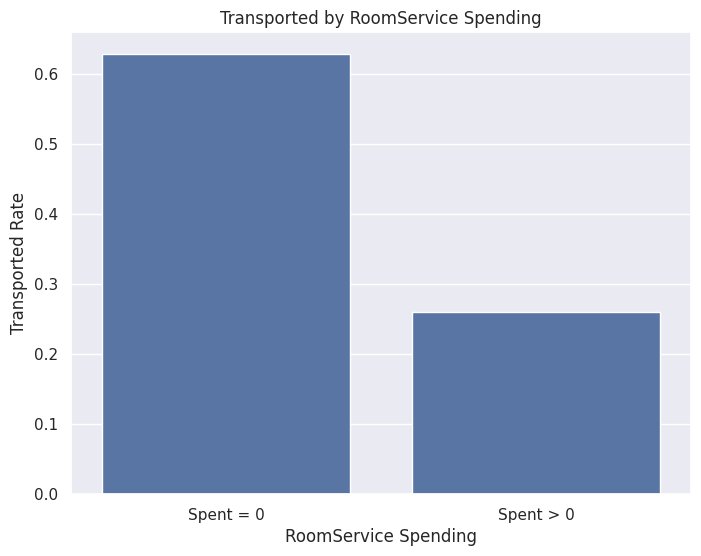

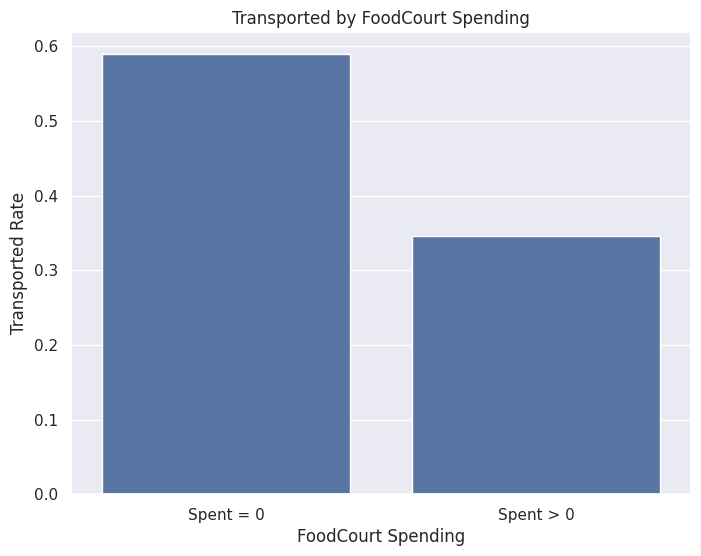

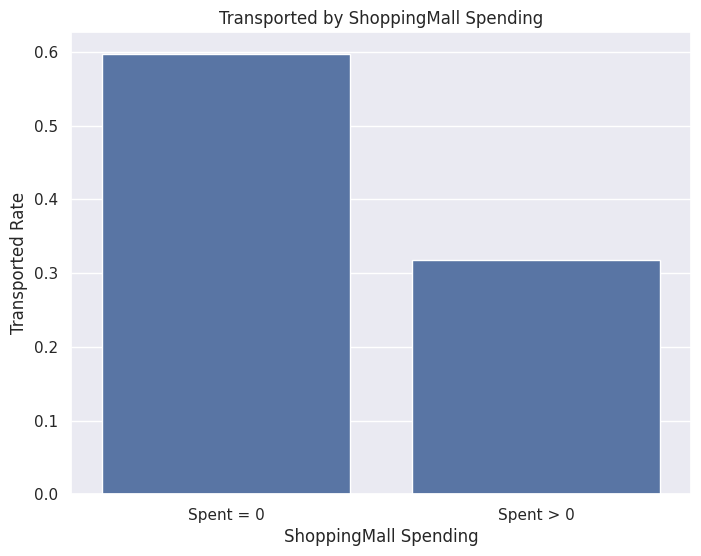

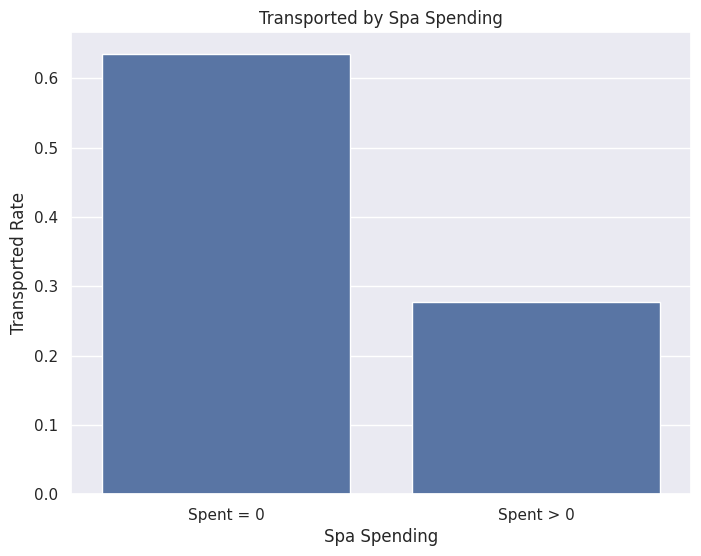

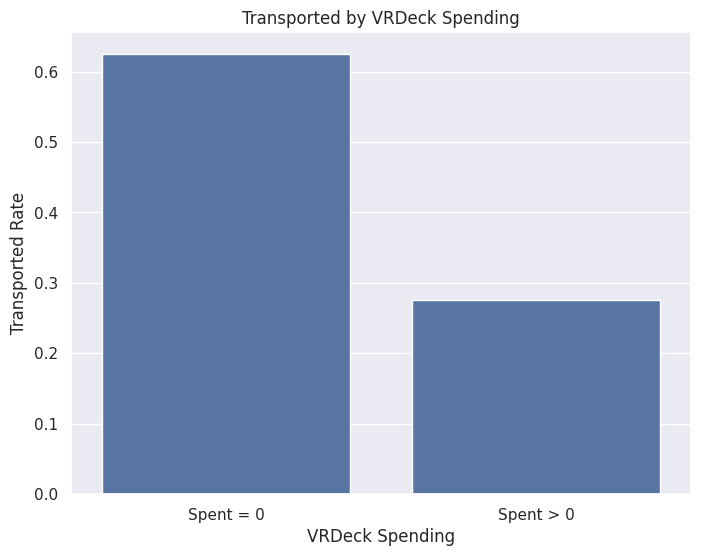

In [13]:
spending_columns = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']

for column in spending_columns:
    cryosleep = (train_ds['CryoSleep'] == True) | (train_ds['CryoSleep'].isnull())
    train_ds.loc[cryosleep & train_ds[column].isnull(), column] = 0

    children_mask = train_ds['Age'] < 13
    train_ds.loc[children_mask & train_ds[column].isnull(), column] = 0

    median_val = train_ds[column].median()
    train_ds[column] = train_ds[column].fillna(median_val)

    train_ds[f'{column}_Spent'] = train_ds[column] > 0

    plt.figure(figsize=(8, 6))
    sns.barplot(x=f'{column}_Spent', y='Transported', data=train_ds, errorbar=None)
    plt.title(f'Transported by {column} Spending')
    plt.xlabel(f'{column} Spending')
    plt.ylabel('Transported Rate')
    plt.xticks([0, 1], ['Spent = 0', 'Spent > 0'])
    plt.show()

columns_to_drop = ['FoodCourt_Spent', 'ShoppingMall_Spent', 'Spa_Spent', 'VRDeck_Spent', 'RoomService_Spent']
train_ds = train_ds.drop(columns_to_drop, axis=1, errors='ignore')

у людей без трат шанс на транспортировку намного выше

In [14]:
age_avg = train_ds['Age'].mean()
age_std = train_ds['Age'].std()
age_null_count = train_ds['Age'].isnull().sum()

if age_null_count > 0:
    age_null_random_list = np.random.randint(age_avg - age_std, age_avg + age_std, size=age_null_count)
    train_ds.loc[train_ds['Age'].isnull(), 'Age'] = age_null_random_list
    train_ds['Age'] = train_ds['Age'].astype(int)

пропуски в возрасте заполняем так: сначала ноходим средний возраст, потом стандартное отклонение от среднего и в диапазоне (ср - откл, ср + откл) генерируем рандомные целые числа и вставляем их в пропуски

Text(0.5, 0, 'Age')

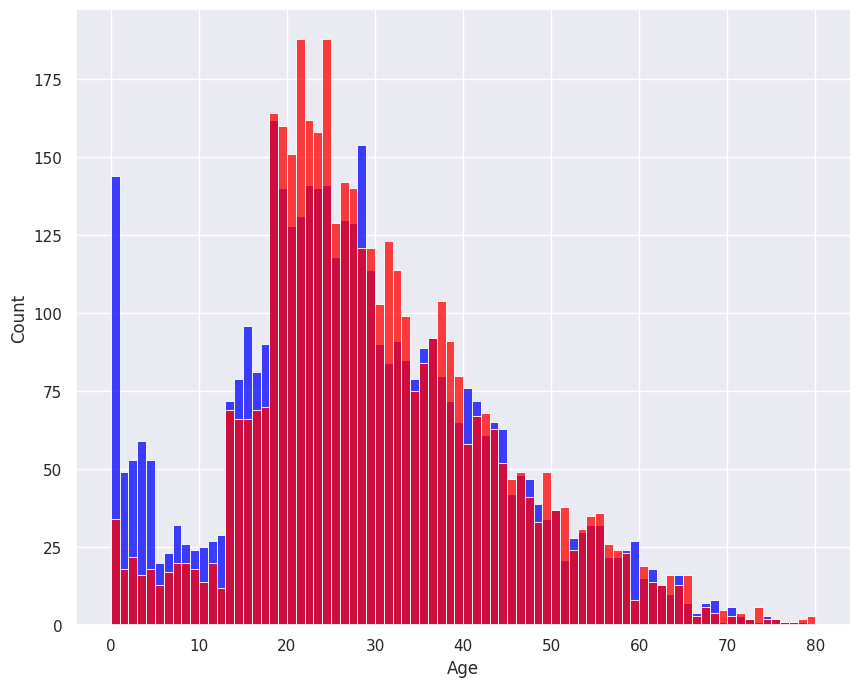

In [15]:
total_Transported = train_ds[train_ds['Transported']==1]
total_not_Transported = train_ds[train_ds['Transported']==0]

fig = plt.figure(figsize=[10, 8])
ax1 = fig.add_subplot(111)
sns.histplot(total_Transported['Age'].dropna().values, bins=range(0, 81, 1), kde=False, color='blue', ax = ax1)
sns.histplot(total_not_Transported['Age'].dropna().values, bins=range(0, 81, 1), kde=False, color='red', ax = ax1)
ax1.set_xlabel("Age")

у детей до 12 лет шанс на трансп. высокий

с 18 до 30 шансы примерно равны

In [16]:
train_ds[["Deck", "Cabin_num", "Side"]] = train_ds["Cabin"].str.split("/", expand=True)

In [17]:
max_cabin = train_ds['Cabin'].str.extract(r'/(\d+)/').astype(float).max().iloc[0]

cabin_null_mask = train_ds['Cabin'].isnull()
cabin_null_count = cabin_null_mask.sum()

if cabin_null_count > 0:
    np.random.seed(42)
    random_cabins = np.random.randint(1, max_cabin, size=cabin_null_count)
    train_ds.loc[cabin_null_mask, 'Cabin'] = random_cabins

train_ds['LastName'] = train_ds['Name'].str.split().str[-1]

lastname_groups = train_ds.groupby('LastName')

for lastname, group in lastname_groups:
    if len(group) > 1:
        valid_passenger = None

        for idx, passenger in group.iterrows():
            if pd.notna(passenger['Cabin']) and pd.notna(passenger['Deck']):
                valid_passenger = passenger
                break

        if valid_passenger is not None:
            valid_cabin = valid_passenger['Cabin']
            valid_deck = valid_passenger['Deck']
            valid_side = valid_passenger['Side']

            train_ds.loc[group.index, 'Cabin'] = valid_cabin
            train_ds.loc[group.index, 'Deck'] = valid_deck
            train_ds.loc[group.index, 'Side'] = valid_side

train_ds = train_ds.drop('LastName', axis=1)
train_ds = train_ds.drop('Cabin', axis=1)

пропуски в кабинах заполняем рандомными числами от 1 до максимального имеющегося номера кабины

дальше группируем пассажиров по фамилиям

у каждой группы будут совпадать Cabin, Deck, Side

In [18]:
train_ds['Deck'] = train_ds['Deck'].fillna(train_ds['Deck'].mode()[0])
train_ds['Side'] = train_ds['Side'].fillna(train_ds['Side'].mode()[0])
train_ds = train_ds.drop('Name', axis=1)

оставшиеся пропуски заполним самым частым значением, столбец Name удалим

все изменения потворим с test_ds

In [19]:
test_ds['CryoSleep'] = test_ds['CryoSleep'].fillna(test_ds['CryoSleep'].mode()[0])
test_ds['VIP'] = test_ds['VIP'].fillna(test_ds['VIP'].mode()[0])

test_ds['HomePlanet'] = test_ds['HomePlanet'].fillna('Earth')

test_ds['Destination'] = test_ds['Destination'].fillna('TRAPPIST-1e')

spending_columns = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']

for column in spending_columns:
    cryosleep = (test_ds['CryoSleep'] == True) | (test_ds['CryoSleep'].isnull())
    test_ds.loc[cryosleep & test_ds[column].isnull(), column] = 0

    children_mask = test_ds['Age'] < 13
    test_ds.loc[children_mask & test_ds[column].isnull(), column] = 0

    median_val = test_ds[column].median()
    test_ds[column] = test_ds[column].fillna(median_val)

age_avg = test_ds['Age'].mean()
age_std = test_ds['Age'].std()
age_null_count = test_ds['Age'].isnull().sum()

if age_null_count > 0:
    age_null_random_list = np.random.randint(age_avg - age_std, age_avg + age_std, size=age_null_count)
    test_ds.loc[test_ds['Age'].isnull(), 'Age'] = age_null_random_list
    test_ds['Age'] = test_ds['Age'].astype(int)

test_ds[["Deck", "Cabin_num", "Side"]] = test_ds["Cabin"].str.split("/", expand=True)

max_cabin = test_ds['Cabin'].str.extract(r'/(\d+)/').astype(float).max().iloc[0]

cabin_null_mask = test_ds['Cabin'].isnull()
cabin_null_count = cabin_null_mask.sum()

if cabin_null_count > 0:
    np.random.seed(42)
    random_cabins = np.random.randint(1, max_cabin, size=cabin_null_count)
    test_ds.loc[cabin_null_mask, 'Cabin'] = random_cabins

test_ds['LastName'] = test_ds['Name'].str.split().str[-1]

lastname_groups = test_ds.groupby('LastName')

for lastname, group in lastname_groups:
    if len(group) > 1:
        valid_passenger = None

        for idx, passenger in group.iterrows():
            if pd.notna(passenger['Cabin']) and pd.notna(passenger['Deck']):
                valid_passenger = passenger
                break

        if valid_passenger is not None:
            valid_cabin = valid_passenger['Cabin']
            valid_deck = valid_passenger['Deck']
            valid_side = valid_passenger['Side']

            test_ds.loc[group.index, 'Cabin'] = valid_cabin
            test_ds.loc[group.index, 'Deck'] = valid_deck
            test_ds.loc[group.index, 'Side'] = valid_side

test_ds = test_ds.drop('LastName', axis=1)
test_ds = test_ds.drop('Cabin', axis=1)

test_ds['Deck'] = test_ds['Deck'].fillna(test_ds['Deck'].mode()[0])
test_ds['Side'] = test_ds['Side'].fillna(test_ds['Side'].mode()[0])

test_ds = test_ds.drop('Name', axis=1)

/tmp/ipython-input-3446858072.py:1: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  test_ds['CryoSleep'] = test_ds['CryoSleep'].fillna(test_ds['CryoSleep'].mode()[0])
/tmp/ipython-input-3446858072.py:2: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  test_ds['VIP'] = test_ds['VIP'].fillna(test_ds['VIP'].mode()[0])


все пропуски заполнены :)

In [20]:
categorical_columns = ['HomePlanet', 'CryoSleep', 'Destination', 'VIP', 'Deck', 'Side', 'Transported']

for column in categorical_columns:
    if column in test_ds.columns:
        unique_values = test_ds[column].unique()
        value_to_number = {value: idx for idx, value in enumerate(sorted(unique_values))}
        test_ds[column] = test_ds[column].map(value_to_number)
    if column in train_ds.columns:
        unique_values = train_ds[column].unique()
        value_to_number = {value: idx for idx, value in enumerate(sorted(unique_values))}
        train_ds[column] = train_ds[column].map(value_to_number)

<Axes: >

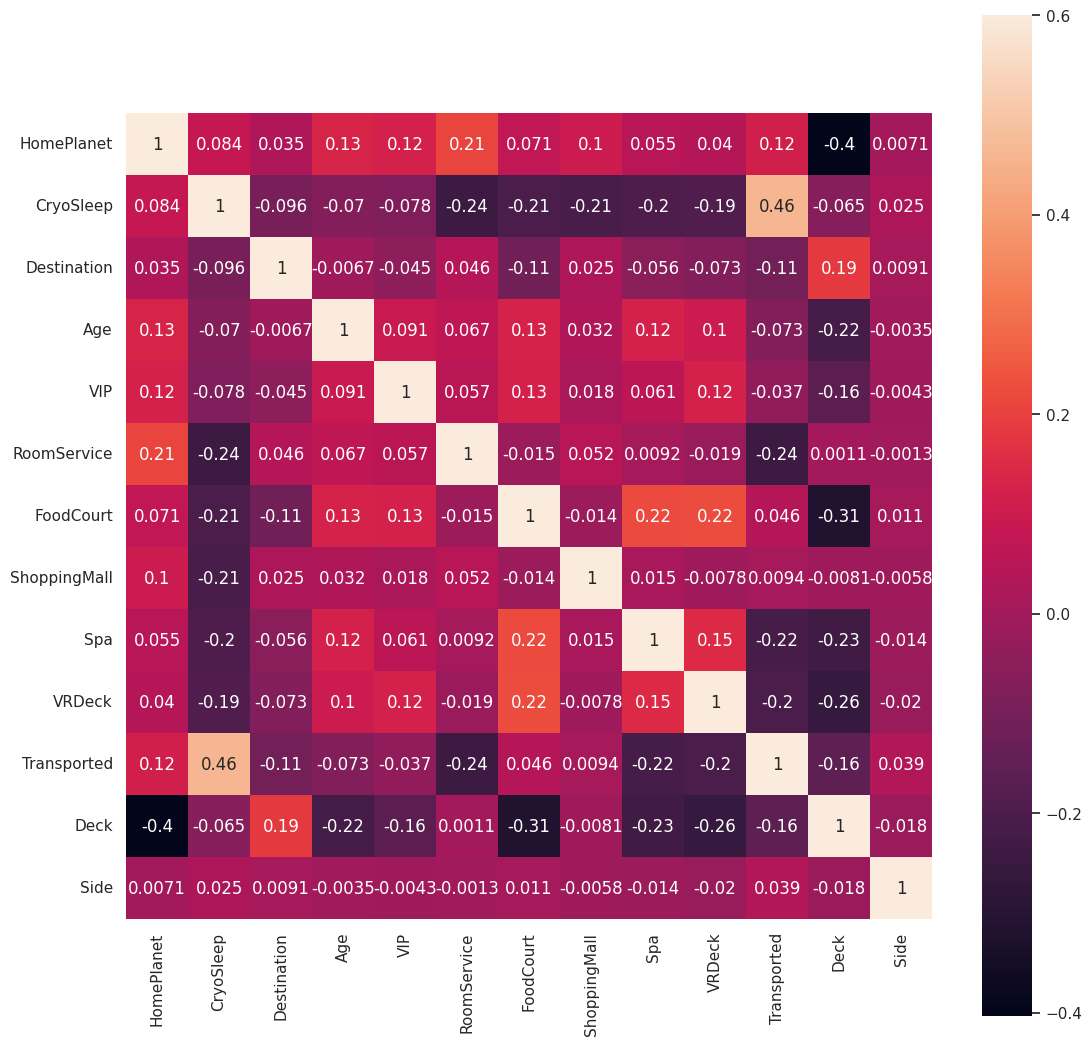

In [21]:
numeric_columns = train_ds.select_dtypes(include=['number'] )
corr_matrix = numeric_columns.corr()
plt.figure(figsize=(13, 13))
sns.heatmap(corr_matrix, vmax=0.6, square=True, annot=True)

In [22]:
X_train = train_ds.drop(['Transported', 'PassengerId'], axis=1)
y_train = train_ds['Transported']

X_test = test_ds.drop("PassengerId", axis=1).copy()

X_train.shape, y_train.shape, X_test.shape

((8693, 13), (8693,), (4277, 13))

In [23]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score

In [24]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=7,
    random_state=42
)
rf_scores = cross_val_score(rf_model, X_train, y_train, cv=5, scoring='accuracy')
print(f"Random Forest CV Accuracy: {rf_scores.mean():.4f} (+/- {rf_scores.std() * 2:.4f})")

rf_model.fit(X_train, y_train)
rf_train_score = accuracy_score(y_train, rf_model.predict(X_train))
print(f"Random Forest Train Accuracy: {rf_train_score:.4f}")

Random Forest CV Accuracy: 0.7904 (+/- 0.0195)
Random Forest Train Accuracy: 0.8132


In [25]:
test_predictions = rf_model.predict(X_test)

submission = pd.DataFrame({
    'PassengerId': test_ds['PassengerId'],
    'Transported': test_predictions
})

submission.Transported = submission.Transported.astype(bool)
submission.to_csv('submission.csv', index=False)

на kaggle получается точность 0,79752

/tmp/ipython-input-1101247390.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feature_importance, x='importance', y='feature', palette='viridis')


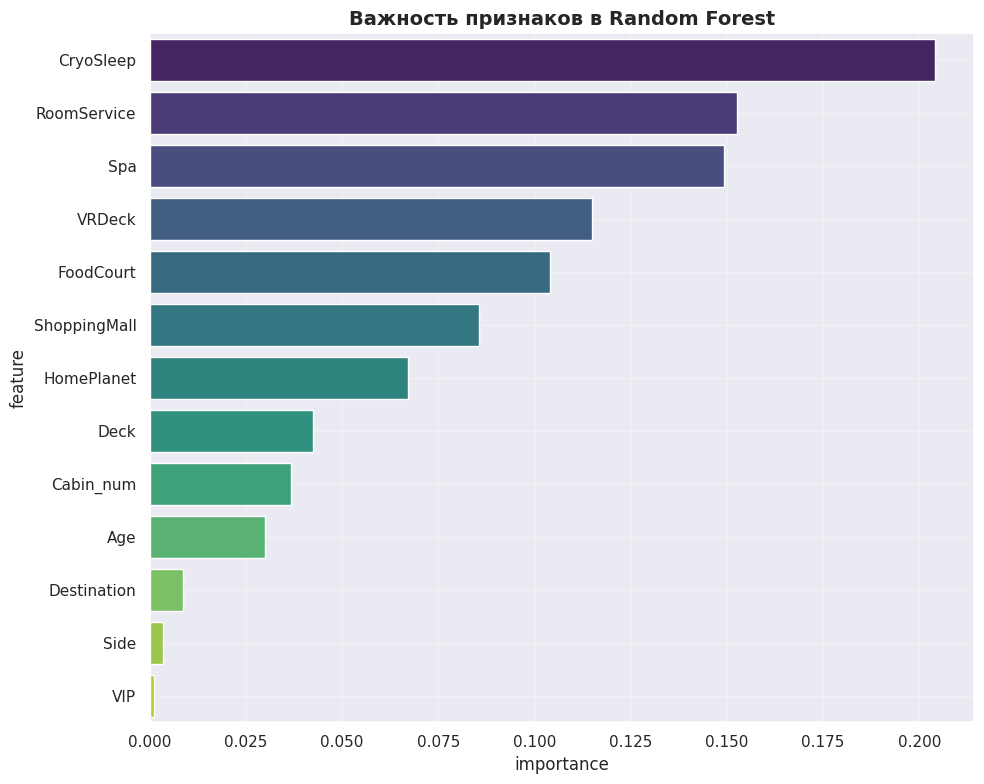

In [26]:
feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(data=feature_importance, x='importance', y='feature', palette='viridis')
plt.title('Важность признаков в Random Forest', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()